## EDA - meetup.com Data from Kaggle

### Imports and Data Download

In [1]:
# General
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import OneHotEncoder

# Data download
import kagglehub
import shutil

# Plotting 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Specific to network purposes
import networkx as nx

In [2]:
downloaded_path = kagglehub.dataset_download("stkbailey/nashville-meetup")
dest_path = "data/raw/"
os.makedirs(os.path.dirname(dest_path), exist_ok=True)

shutil.copytree(downloaded_path, dest_path, dirs_exist_ok=True)
print(f"Dataset moved to: {dest_path}")

Dataset moved to: data/raw/


In [3]:
data_dir = 'data/raw/'

# The files 
files_to_check = [
    'meta-events.csv',
    'meta-groups.csv',
    'meta-members.csv',
    'rsvps.csv',
    'member-to-group-edges.csv',
    'member-edges.csv',
    'group-edges.csv'
]

for file in files_to_check:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        print(f"========== {file} ==========")
        # Read first 3 rows
        df = pd.read_csv(file_path, nrows=3)
        print(f"COLUMNS: {df.columns.tolist()}\n")
        print(df)
        print("\n")
    else:
        print(f"========== {file} NOT FOUND ==========\n")

========== meta-events.csv ==========
COLUMNS: ['event_id', 'group_id', 'name', 'time']

       event_id  group_id                                               name  \
0     243930425  26140018  2017 Nashville Walk to End Alzheimers - Octob...   
1     244208851  25604533                          Steak Dinner on the Patio   
2  pxlktnywnbfb  25973656                                    Schedule Meetup   

                  time  
0  2017-10-14 12:00:00  
1  2017-10-15 00:15:00  
2  2017-10-03 23:30:00  


========== meta-groups.csv ==========
COLUMNS: ['group_id', 'group_name', 'num_members', 'category_id', 'category_name', 'organizer_id', 'group_urlname']

   group_id                        group_name  num_members  category_id  \
0    339011           Nashville Hiking Meetup        15838           23   
1  19728145  Stepping Out Social Dance Meetup         1778            5   
2   6335372                  Nashville soccer         2869           32   

          category_name  organiz

### Data Processing and Cleaning

- Handle missing values and duplicates

- One-hot encode categorical variables

- Normalization/scaling?

In [4]:
# Load data (dropping the artifact 'Unnamed: 0' columns immediately)
events_df = pd.read_csv(os.path.join(data_dir, 'meta-events.csv'))
groups_df = pd.read_csv(os.path.join(data_dir, 'meta-groups.csv'))
mem_df = pd.read_csv(os.path.join(data_dir, 'meta-members.csv'), index_col='member_id') # Index col setting attribution: Stephen Bailey
rsvps_df = pd.read_csv(os.path.join(data_dir, 'rsvps.csv')).drop(columns=['Unnamed: 0'], errors='ignore')
mem_grp_edges = pd.read_csv(os.path.join(data_dir, 'member-to-group-edges.csv'))
mem_edges = pd.read_csv(os.path.join(data_dir, 'member-edges.csv')).drop(columns=['Unnamed: 0'], errors='ignore')
grp_edges = pd.read_csv(os.path.join(data_dir, 'group-edges.csv')).drop(columns=['Unnamed: 0'], errors='ignore')

# Convert event times to datetime objects
events_df['time'] = pd.to_datetime(events_df['time'], errors='coerce')

# Merge event timestamps and group IDs into the RSVP dataframe
rsvps_master = rsvps_df.merge(events_df[['event_id', 'time', 'name']], on='event_id', how='left')
rsvps_master = rsvps_master.merge(groups_df[['group_id', 'category_name', 'category_id']], on='group_id', how='left')

all_data = {"Events": events_df, "Groups": groups_df, "Members": mem_df, "RSVPs Master": rsvps_master, 
            "Member-Group Edges": mem_grp_edges, "Member Edges": mem_edges, "Group Edges": grp_edges}

for key, value in all_data.items():
    print(f"--- {key} Table ---")
    print(value.info())
    print(f"Missing Values: \n{value.isna().sum()}")
    print(f"Duplicate Values: {value.duplicated().sum()}\n")

--- Events Table ---
<class 'pandas.DataFrame'>
RangeIndex: 19307 entries, 0 to 19306
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   event_id  19307 non-null  str           
 1   group_id  19307 non-null  int64         
 2   name      19307 non-null  str           
 3   time      19169 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 603.5 KB
None
Missing Values: 
event_id      0
group_id      0
name          0
time        138
dtype: int64
Duplicate Values: 0

--- Groups Table ---
<class 'pandas.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   group_id       602 non-null    int64
 1   group_name     602 non-null    str  
 2   num_members    602 non-null    int64
 3   category_id    602 non-null    int64
 4   category_name  602 non-null    str  
 5   organi

In [ ]:
# Out of over 125K entries in rsvps_master, fewer than 500 are missing timestamps (no other cols are missing vals); drop these rows
rsvps_master = rsvps_master.dropna()

# Fewer than 200 timestamps missing from Events table, drop these are well
events_df = events_df.dropna()

# 19,664 are missing hometown - too many to drop - replace with 

In [ ]:
# All categorical variables
cats = ['event_id', 'group_id', 'name', 'group_name', 'category_id', 'category_name', 'organizer_id', 'group_urlname', 'member_id']

# Set up one hot encoder
encoder = OneHotEncoder(sparse_output=False)

for key, value in all_data.items():
    # Also strip whitespace from string/object columns
    valie = value.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    # One hot encode
    cols_to_encode = [col for col in cats if col in value.columns]
    if cols_to_encode:
        one_hot_encoded = encoder.fit_transform(value[cols_to_encode])

In [13]:
rsvps_series = pd.Series(rsvps_master.groupby('event_id').size(), name="num_rsvps")
event_sizes = rsvps_series.to_frame()
event_sizes

,num_rsvps
event_id,
107248742,2
117878862,61
133313452,23
145868842,5
160315242,68
...,...
zxlwkmywjblb,31
zxnlxlyvnbbc,6
zxnlxlyvnbjb,7


### Plotting and Exploration

/var/folders/v4/nmf8gnpn5vb2t2vlt0df52mh0000gn/T/ipykernel_1145/3302362178.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')


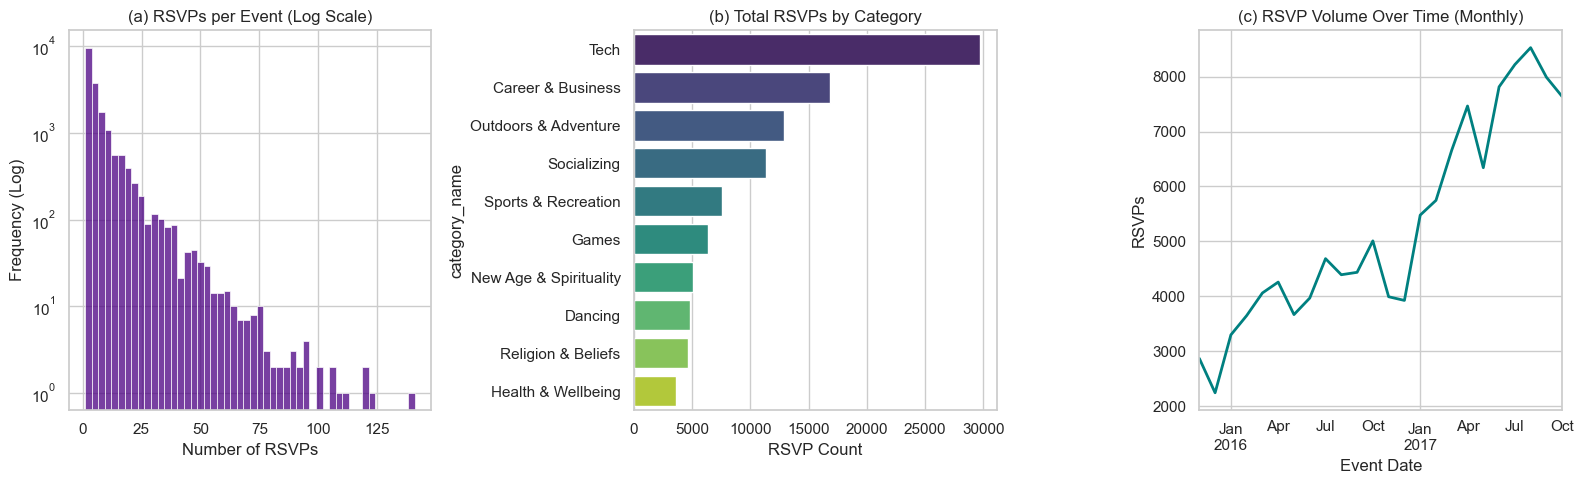


--- Event Size Statistics ---
          num_rsvps
count  18893.000000
mean       6.686551
std        9.369866
min        1.000000
50%        3.000000
75%        8.000000
90%       16.000000
95%       23.000000
99%       48.000000
max      141.000000


In [14]:
plt.figure(figsize=(16, 5))

# --- Plot 1: Event Size Distribution ---
# How many RSVPs does a typical event get?

plt.subplot(1, 3, 1)
sns.histplot(event_sizes, x='num_rsvps',  bins=50, color='indigo')
plt.yscale('log') # Added to fix log scale definition issue within sns
plt.title('(a) RSVPs per Event (Log Scale)')
plt.xlabel('Number of RSVPs')
plt.ylabel('Frequency (Log)')

# --- Plot 2: Category Popularity ---
# Which domains drive the most interaction? 
plt.subplot(1, 3, 2)
category_counts = rsvps_master['category_name'].value_counts().head(10)
sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')
plt.title('(b) Total RSVPs by Category')
plt.xlabel('RSVP Count')

# --- Plot 3: Temporal Event Frequency ---
# Identifying the timeline for your train/val/test split
plt.subplot(1, 3, 3)
rsvps_master.set_index('time').resample('ME').size().plot(color='teal', lw=2)
plt.title('(c) RSVP Volume Over Time (Monthly)')
plt.xlabel('Event Date')
plt.ylabel('RSVPs')

plt.tight_layout()
plt.show()

print("\n--- Event Size Statistics ---")
print(event_sizes.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

In [16]:
mem_edges.head()

,member1,member2,weight
0,198737924,220654721,1
1,198737924,208201738,1
2,198737924,88664332,1
3,198737924,8640526,1
4,198737924,56356372,1


In [24]:
print(mem_edges.columns.tolist())
print(mem_edges[['member1', 'member2', 'weight']].head())

['member1', 'member2', 'weight']
     member1    member2  weight
0  198737924  220654721       1
1  198737924  208201738       1
2  198737924   88664332       1
3  198737924    8640526       1
4  198737924   56356372       1


In [ ]:
import networkx as nx

subset = mem_edges.head(5000).dropna(subset=['member1', 'member2']).copy()


G_sample = nx.from_pandas_edgelist(
    subset,
    source='member1',
    target='member2',
    edge_attr='weight',
    create_using=nx.Graph()
)

assert G_sample is not None, "Graph creation returned None"
print(f"Nodes: {G_sample.number_of_nodes()}, Edges: {G_sample.number_of_edges()}")

Nodes: 3841, Edges: 5000


--- Analyzing Pre-computed Member Graph ---
Total Edges Provided: 1176368
Sample Graph Nodes: 3841
Sample Graph Edges: 5000


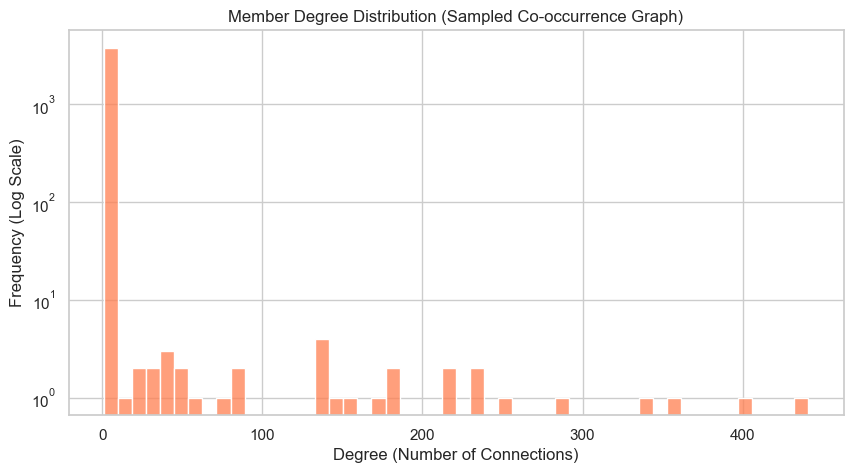


--- Edge Weight Summary ---
count    1.176368e+06
mean     1.047387e+00
std      2.501198e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: weight, dtype: float64


In [27]:
print("--- Analyzing Pre-computed Member Graph ---")
print(f"Total Edges Provided: {len(mem_edges)}")

# Build a graph sample to calculate structural properties efficiently
# Using top 5,000 edges to avoid memory issues and excessive computational time during EDA
subset = mem_edges.head(5000).copy().reset_index(drop=True)
G_sample = nx.from_pandas_edgelist(
    subset,
    source='member1',
    target='member2',
    edge_attr='weight',
    create_using=nx.Graph())
# Set attributes , ex btwnness centrality
bb = nx.betweenness_centrality(G_sample)
nx.set_node_attributes(G_sample, bb, 'betweenness')

print(f"Sample Graph Nodes: {G_sample.number_of_nodes()}")
print(f"Sample Graph Edges: {G_sample.number_of_edges()}")

# Calculate Degree Distribution
degrees = [d for n, d in G_sample.degree()]

plt.figure(figsize=(10, 5))
sns.histplot(degrees, bins=50, color='coral')
plt.yscale('log')
plt.title('Member Degree Distribution (Sampled Co-occurrence Graph)')
plt.xlabel('Degree (Number of Connections)')
plt.ylabel('Frequency (Log Scale)')
plt.show()

# Check weight distribution to validate edge decay viability
print("\n--- Edge Weight Summary ---")
print(mem_edges['weight'].describe())

In [37]:
print(f"Type of graph object: {type(G_sample)}")

Type of graph object: <class 'NoneType'>
